# Experiment with MLflow Tracking

This notebook extends `1_tf_experiment_train.ipynb` with MLflow autologging.
It trains the same Keras fraud-detection model and logs metrics, hyperparameters,
the trained model, and the ONNX export to the cluster MLflow server.

## Install Python dependencies

In [6]:
%%capture
%pip install tensorflow mlflow tf2onnx onnxruntime --extra-index-url https://pypi.org/simple/ -q

Import the dependencies for the model training code:

In [7]:
import os
import warnings

# Suppress TensorFlow and ABSL logging before any TF/Keras import
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import datetime
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import tf2onnx
import onnx
import pickle
from pathlib import Path

The output might show TensorFlow messages, such as a "Could not find TensorRT" warning. You can ignore these messages.


## Load the CSV data

The CSV data that you use to train the model contains the following fields:

* **distancefromhome** - The distance from home where the transaction happened.
* **distancefromlast_transaction** - The distance from the last transaction that happened.
* **ratiotomedianpurchaseprice** - The ratio of purchased price compared to median purchase price.
* **repeat_retailer** - If it's from a retailer that already has been purchased from before.
* **used_chip** - If the credit card chip was used.
* **usedpinnumber** - If the PIN number was used.
* **online_order** - If it was an online order.
* **fraud** - If the transaction is fraudulent.

In [8]:
# Set the input (X) and output (Y) data. 
# The only output data is whether it's fraudulent. All other fields are inputs to the model.

feature_indexes = [
    1,  # distance_from_last_transaction
    2,  # ratio_to_median_purchase_price
    4,  # used_chip
    5,  # used_pin_number
    6,  # online_order
]

label_indexes = [
    7  # fraud
]

df = pd.read_csv('data/train.csv')
X_train = df.iloc[:, feature_indexes].values
y_train = df.iloc[:, label_indexes].values

df = pd.read_csv('data/validate.csv')
X_val = df.iloc[:, feature_indexes].values
y_val = df.iloc[:, label_indexes].values

df = pd.read_csv('data/test.csv')
X_test = df.iloc[:, feature_indexes].values
y_test = df.iloc[:, label_indexes].values


# Scale the data to remove mean and have unit variance. The data will be between -1 and 1, which makes it a lot easier for the model to learn than random (and potentially large) values.
# It is important to only fit the scaler to the training data, otherwise you are leaking information about the global distribution of variables (which is influenced by the test set) into the training set.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Path("artifact").mkdir(parents=True, exist_ok=True)
with open("artifact/test_data.pkl", "wb") as handle:
    pickle.dump((X_test, y_test), handle)
with open("artifact/scaler.pkl", "wb") as handle:
    pickle.dump(scaler, handle)

# Since the dataset is unbalanced (it has many more non-fraud transactions than fraudulent ones), set a class weight to weight the few fraudulent transactions higher than the many non-fraud transactions.
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train.ravel())
class_weights = {i : class_weights[i] for i in range(len(class_weights))}

## Build the model

The model is a simple, fully-connected, deep neural network, containing three hidden layers and one output layer.

In [9]:
from keras import Input

model = Sequential()
model.add(Input(shape=(len(feature_indexes),)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))
model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1781396407.457935      74 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20833 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:31:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,465 (9.63 KB)

 Non-trainable params: 128 (512.00 B)

### Configure MLflow experiment tracking

MLflow autolog captures all Keras metrics (loss, accuracy per epoch), hyperparameters,
and the trained model automatically during `model.fit()`.  
Set `MLFLOW_TRACKING_URI` as a workbench environment variable to point at the cluster MLflow server.

In [ ]:
import mlflow
import os

# MLflow's S3 artifact client uses MLFLOW_S3_ENDPOINT_URL, NOT AWS_S3_ENDPOINT.
# Without this, boto3 builds virtual-hosted URLs like
#   models.s3.<region>.amazonaws.com  → connection refused on a private cluster.
s3_endpoint = os.environ.get("AWS_S3_ENDPOINT")
if s3_endpoint:
    os.environ["MLFLOW_S3_ENDPOINT_URL"] = s3_endpoint

mlflow.set_tracking_uri(
    os.environ.get("MLFLOW_TRACKING_URI", "https://mlflow.redhat-ods-applications.svc:8443")
)
mlflow.set_experiment("fraud-detection")

# autolog starts a run automatically on model.fit() and logs:
#   - hyperparams: optimizer, learning_rate, epochs, batch_size
#   - metrics:     loss + accuracy at each epoch (train + val)
#   - model:       Keras SavedModel artifact
mlflow.tensorflow.autolog(registered_model_name="fraud-detection")

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {mlflow.get_experiment_by_name('fraud-detection').name}")
print(f"S3 endpoint  : {os.environ.get('MLFLOW_S3_ENDPOINT_URL', '(not set)')}")

## Train the model

Training a model is often the most time-consuming part of the machine learning process.  Large models can take multiple GPUs for days.  Expect the training on CPU for this very simple model to take a minute or more.

In [11]:
# Train the model and get performance
import os
import time

start = time.time()
epochs = 2
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    validation_data=(X_val, y_val),
    verbose=True,
    class_weight=class_weights
)
end = time.time()
print(f"Training of model is complete. Took {end-start} seconds")

2026/06/14 00:20:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3a073e7d0826480e9c8bbb5623819bdd', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow


2026/06/14 00:20:24 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Could not connect to the endpoint URL: "https://models.s3.local.amazonaws.com/mlflow/workspaces/fraud-detection/1/3a073e7d0826480e9c8bbb5623819bdd/artifacts/model_summary.txt"


Epoch 1/2


I0000 00:00:1781396426.281531     153 service.cc:153] XLA service 0x7f2ba2c1b140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781396426.281562     153 service.cc:161]   StreamExecutor [0]: NVIDIA L4, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.8.0; DNN: 9.19.1)
I0000 00:00:1781396426.307568     153 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781396426.517064     153 cuda_dnn.cc:461] Loaded cuDNN version 91901
I0000 00:00:1781396426.581237     153 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2648__.20


   51/18750 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6965 - loss: 0.6103

...

18750/18750 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.9286 - loss: 0.2603 - val_accuracy: 0.9442 - val_loss: 0.2305
Epoch 2/2
18740/18750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9446 - loss: 0.2404

2026/06/14 00:22:11 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Could not connect to the endpoint URL: "https://models.s3.local.amazonaws.com/mlflow/workspaces/fraud-detection/1/3a073e7d0826480e9c8bbb5623819bdd/artifacts/checkpoints/latest_checkpoint_metrics.json"


18750/18750 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - accuracy: 0.9460 - loss: 0.2374 - val_accuracy: 0.9516 - val_loss: 0.2226
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


2026/06/14 00:22:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 00:22:12 WARNING mlflow.utils.requirements_utils: Found tensorflow version (2.21.0+redhat) contains a local version label (+redhat). MLflow logged a pip requirement for this package as 'tensorflow==2.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 00:22:19 WARNING mlflow.utils.requirements_utils: Found tensorflow version (2.21.0+redhat) contains a local version label (+redhat). MLflow logged a pip requirement for this package as 'tensorflow==2.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 00:22:25 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autolo

🏃 View run placid-roo-454 at: https://rh-ai.apps.cluster-7hb2t.7hb2t.sandbox670.opentlc.com/mlflow/#/experiments/1/runs/3a073e7d0826480e9c8bbb5623819bdd?workspace=fraud-detection
🧪 View experiment at: https://rh-ai.apps.cluster-7hb2t.7hb2t.sandbox670.opentlc.com/mlflow/#/experiments/1?workspace=fraud-detection
Training of model is complete. Took 127.99307870864868 seconds


## Save the model file

In [12]:
import tensorflow as tf
import numpy as np
# Patch np.cast removed in NumPy 2.0, required by tf2onnx 1.16.1's rewriter
if not hasattr(np, 'cast'):
    class _NpCast:
        def __getitem__(self, dtype):
            return lambda x: np.asarray(x, dtype=dtype)
    np.cast = _NpCast()

# Normally we use tf2.onnx.convert.from_keras.
# workaround for tf2onnx bug https://github.com/onnx/tensorflow-onnx/issues/2348

# Wrap the model in a `tf.function`
@tf.function(input_signature=[tf.TensorSpec([None, X_train.shape[1]], tf.float32, name='dense_input')])
def model_fn(x):
    return model(x)

# Convert the Keras model to ONNX
model_proto, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[tf.TensorSpec([None, X_train.shape[1]], tf.float32, name='dense_input')]
)

# Save the model as ONNX for easy use of ModelMesh
os.makedirs("models/fraud/1", exist_ok=True)
onnx.save(model_proto, "models/fraud/1/model.onnx")

I0000 00:00:1781396545.179036      74 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1781396545.179169      74 single_machine.cc:376] Starting new session
I0000 00:00:1781396545.186618      74 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20833 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:31:00.0, compute capability: 8.9
I0000 00:00:1781396545.230258      74 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20833 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:31:00.0, compute capability: 8.9
I0000 00:00:1781396545.235644      74 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1781396545.235833      74 single_machine.cc:376] Starting new session
I0000 00:00:1781396545.243977      74 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20833 MB memory:  -

In [13]:
# Log ONNX model to the run that autolog created during model.fit()
last_run = mlflow.last_active_run()
if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        mlflow.log_artifact("models/fraud/1/model.onnx", artifact_path="onnx-model")
        print(f"ONNX model logged to MLflow run: {last_run.info.run_id}")
        print(f"View run at: {mlflow.get_tracking_uri()}/#/experiments/"
              f"{last_run.info.experiment_id}/runs/{last_run.info.run_id}")
else:
    print("No active MLflow run found — skipping ONNX artifact logging.")

🏃 View run placid-roo-454 at: https://rh-ai.apps.cluster-7hb2t.7hb2t.sandbox670.opentlc.com/mlflow/#/experiments/1/runs/3a073e7d0826480e9c8bbb5623819bdd?workspace=fraud-detection
🧪 View experiment at: https://rh-ai.apps.cluster-7hb2t.7hb2t.sandbox670.opentlc.com/mlflow/#/experiments/1?workspace=fraud-detection


EndpointConnectionError: Could not connect to the endpoint URL: "https://models.s3.local.amazonaws.com/mlflow/workspaces/fraud-detection/1/3a073e7d0826480e9c8bbb5623819bdd/artifacts/onnx-model/model.onnx"

The output might include TensorFlow messages related to GPUs. You can ignore these messages.

## Confirm the model file was created successfully

The output should include the model name, size, and date. 

In [18]:
! ls -alRh ./models/

./models/:
total 12K
drwxr-sr-x.  3 1000830000 1000830000 4.0K Jun 13 21:14 .
drwxrwsr-x. 15 1000830000 1000830000 4.0K Jun 13 21:14 ..
drwxr-sr-x.  3 1000830000 1000830000 4.0K Jun 13 21:14 fraud

./models/fraud:
total 12K
drwxr-sr-x. 3 1000830000 1000830000 4.0K Jun 13 21:14 .
drwxr-sr-x. 3 1000830000 1000830000 4.0K Jun 13 21:14 ..
drwxr-sr-x. 2 1000830000 1000830000 4.0K Jun 13 21:14 1

./models/fraud/1:
total 24K
drwxr-sr-x. 2 1000830000 1000830000 4.0K Jun 13 21:14 .
drwxr-sr-x. 3 1000830000 1000830000 4.0K Jun 13 21:14 ..
-rw-r--r--. 1 1000830000 1000830000  13K Jun 13 21:14 model.onnx


## Test the model

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pickle
import onnxruntime as rt

Load the test data and scaler:

In [22]:
with open('artifact/scaler.pkl', 'rb') as handle:
    scaler = pickle.load(handle)
with open('artifact/test_data.pkl', 'rb') as handle:
    (X_test, y_test) = pickle.load(handle)

Create an ONNX inference runtime session and predict values for all test inputs:

In [23]:
sess = rt.InferenceSession("models/fraud/1/model.onnx", providers=rt.get_available_providers())
input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
y_pred_temp = sess.run([output_name], {input_name: X_test.astype(np.float32)}) 
y_pred_temp = np.asarray(np.squeeze(y_pred_temp[0]))
threshold = 0.95
y_pred = np.where(y_pred_temp > threshold, 1, 0)

Show the results:

Eval Metrics: 
 Accuracy: 97.2%, Precision: 0.9358, Recall: 0.7286 



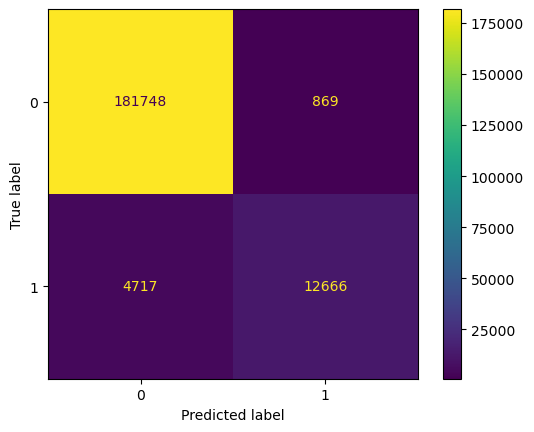

In [24]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_test_arr = y_test.squeeze()
correct = np.equal(y_pred, y_test_arr).sum().item()
acc = (correct / len(y_pred)) * 100
precision = precision_score(y_test_arr, np.round(y_pred))
recall = recall_score(y_test_arr, np.round(y_pred))

print(f"Eval Metrics: \n Accuracy: {acc:>0.1f}%, "
      f"Precision: {precision:.4f}, Recall: {recall:.4f} \n")

c_matrix = confusion_matrix(y_test_arr, y_pred)
ConfusionMatrixDisplay(c_matrix).plot()

## Example: Is Sally's transaction likely to be fraudulent?

Here is the order of the fields from Sally's transaction details:
* distance_from_last_transaction
* ratio_to_median_price
* used_chip 
* used_pin_number
* online_order 

In [25]:
sally_transaction_details = [
    [0.3111400080477545,
    1.9459399775518593,
    1.0,
    0.0,
    0.0]
    ]

prediction = sess.run([output_name], {input_name: scaler.transform(sally_transaction_details).astype(np.float32)})

print("Is Sally's transaction predicted to be fraudulent? (true = YES, false = NO) ")
print(np.squeeze(prediction) > threshold)

print("How likely was Sally's transaction to be fraudulent? ")
print("{:.5f}".format(100 * np.squeeze(prediction)) + "%")

Is Sally's transaction predicted to be fraudulent? (true = YES, false = NO) 
False
How likely was Sally's transaction to be fraudulent? 
0.01798%
